In [7]:
print("Environment working!")

Environment working!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment working!")

Environment working!


In [9]:
import pandas as pd

# Load fake and real news datasets
fake = pd.read_csv("data/raw/fake.csv")
real = pd.read_csv("data/raw/real.csv")

# Check the datasets
print("Fake news shape:", fake.shape)
print("Real news shape:", real.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/fake.csv'

In [11]:
import pandas as pd

# Load the datasets
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

# Check their sizes
print("Fake news shape:", fake.shape)
print("True news shape:", true.shape)

Fake news shape: (23481, 4)
True news shape: (21417, 4)


In [12]:
print("FAKE NEWS:")
display(fake.head())

print("\nTRUE NEWS:")
display(true.head())

FAKE NEWS:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



TRUE NEWS:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [13]:
print("Fake dataset columns:")
print(fake.columns.tolist())

print("\nTrue dataset columns:")
print(true.columns.tolist())

print("\nMissing values in Fake dataset:")
print(fake.isnull().sum())

print("\nMissing values in True dataset:")
print(true.isnull().sum())

Fake dataset columns:
['title', 'text', 'subject', 'date']

True dataset columns:
['title', 'text', 'subject', 'date']

Missing values in Fake dataset:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values in True dataset:
title      0
text       0
subject    0
date       0
dtype: int64


In [14]:
# Add labels
fake["label"] = 0
true["label"] = 1

# Combine both datasets
df = pd.concat([fake, true], ignore_index=True)

# Check the result
print("Combined dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

Combined dataset shape: (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [15]:
print("Columns in our dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns in our dataset:
['title', 'text', 'subject', 'date', 'label']

First 5 rows:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [16]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shuffled successfully!")
display(df.head())

Dataset shuffled successfully!


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


label
0    23481
1    21417
Name: count, dtype: int64


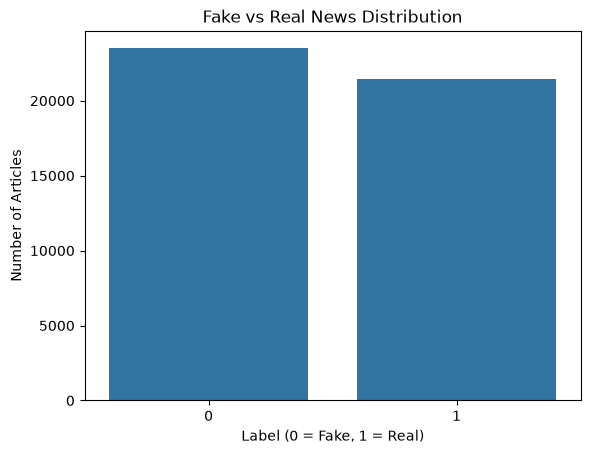

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count fake and real news
print(df["label"].value_counts())

# Visualize the class distribution
sns.countplot(x="label", data=df)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")
plt.show()

In [18]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate article text
print("Duplicate articles:", df["text"].duplicated().sum())

Duplicate rows: 209
Duplicate articles: 6252


In [19]:
# Remove duplicate articles based on article text
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate articles:", df["text"].duplicated().sum())

Dataset shape after removing duplicates: (38646, 5)
Remaining duplicate articles: 0


In [20]:
# Calculate article length
df["text_length"] = df["text"].str.len()

# Basic statistics
print(df["text_length"].describe())

count    38646.000000
mean      2455.888061
std       1936.609582
min          1.000000
25%       1318.000000
50%       2227.000000
75%       3096.000000
max      51794.000000
Name: text_length, dtype: float64


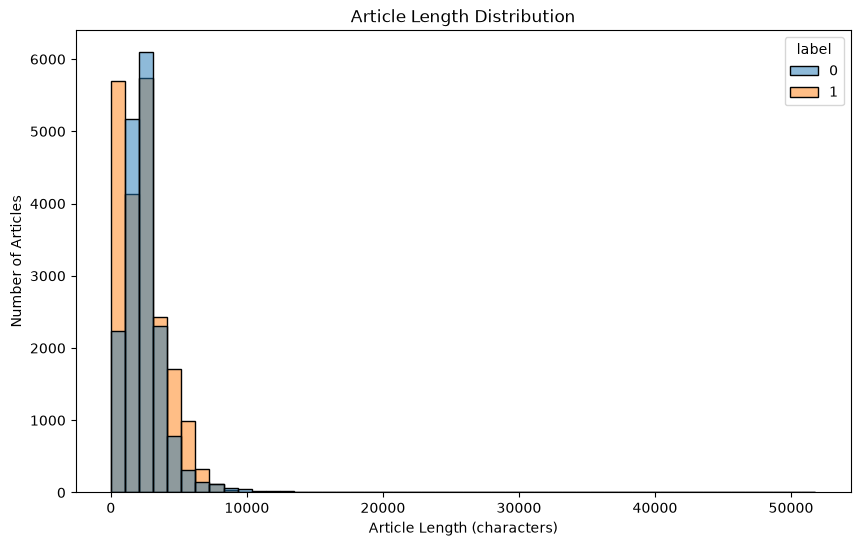

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50
)

plt.title("Article Length Distribution")
plt.xlabel("Article Length (characters)")
plt.ylabel("Number of Articles")
plt.show()

In [22]:
# Display a few random articles
display(df[["title", "text", "label"]].sample(5, random_state=42))

,title,text,label
35898,Trump Just Called A Fledgling Dictator To Con...,It takes one to know one. Turkey just held a r...,0
23304,WATCH: CNN NAILS Trump For Lie That He Would ...,Donald Trump just got caught lying again and t...,0
38275,U.S. 'very concerned' by violence around Iraq'...,WASHINGTON (Reuters) - The U.S. State Departme...,1
21571,"Germany calls for reconciliation, respect for ...",BERLIN (Reuters) - Germany called for reconcil...,1
4156,OOPS! HILLARY’S HIT WOMAN LIED About Trump Gro...,"It should be the lead story on every network, ...",0


In [23]:
display(
    df[["title", "label"]]
    .sample(10, random_state=42)
)

,title,label
35898,Trump Just Called A Fledgling Dictator To Con...,0
23304,WATCH: CNN NAILS Trump For Lie That He Would ...,0
38275,U.S. 'very concerned' by violence around Iraq'...,1
21571,"Germany calls for reconciliation, respect for ...",1
4156,OOPS! HILLARY’S HIT WOMAN LIED About Trump Gro...,0
13902,Fed has limited view on Trump economic policie...,1
24295,Congress subcommittee grills U.S. banks regula...,1
4775,Republican Lawmaker Introduces Bill To Elimin...,0
35269,France sees U.S. strike on Syria as tool to pu...,1
16247,Alleged Islamic State recruiter goes on trial ...,1


In [24]:
# Combine title and article text
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Check the result
display(df[["title", "text", "content", "label"]].head())

,title,text,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",Donald Trump heads for Scotland to reopen a go...,1


In [25]:
df.to_csv("../data/processed_news.csv", index=False)

print("Prepared dataset saved successfully!")
print("Final dataset shape:", df.shape)

Prepared dataset saved successfully!
Final dataset shape: (38646, 7)
